Implied avg winner: 1.914R | avg loser: 1.000R (winrate=35%, expectancy=0.02R)
Risk per trade: $100 (fixed, = 1R)
Trades per day: 3 (ASSUMED - edit TRADES_PER_DAY to match your strategy)

--- Monte Carlo results over 20,000 simulated challenges ---
    passed:   6460  (32.3%)
    failed:  13090  (65.5%)
incomplete:    450  (2.2%)

Estimated probability of passing: 32.30%

Chart saved to prop_firm_montecarlo.png


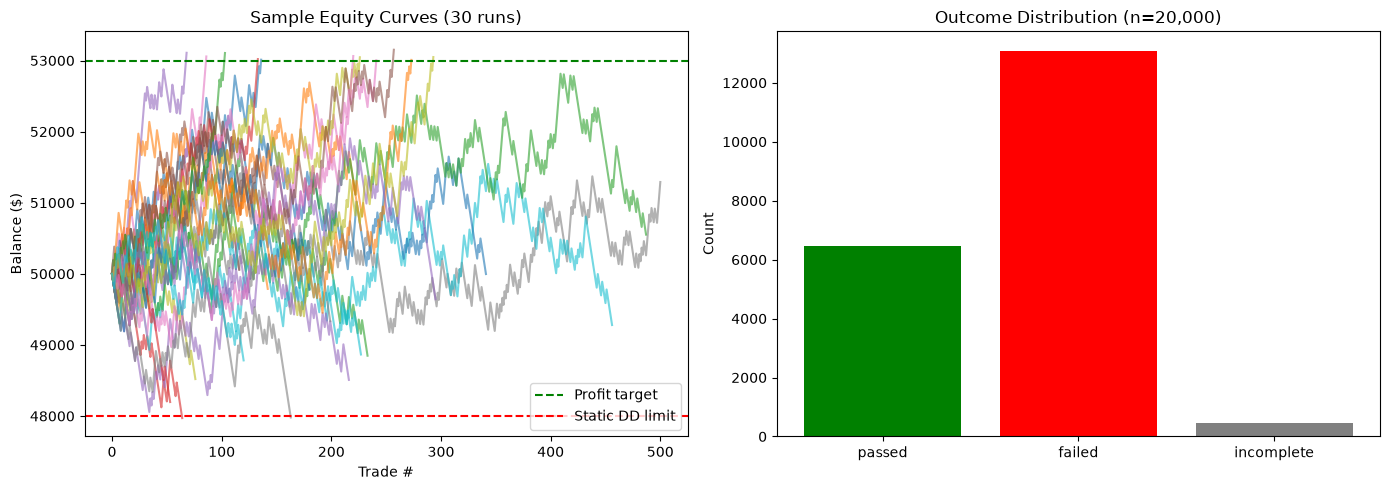

In [ ]:
"""
Prop Firm Challenge Monte Carlo Simulator
==========================================
Simulates trade-by-trade equity paths for a strategy with a given
win rate and expectancy, and estimates the probability of passing
a prop firm challenge (hitting the profit target before breaching
the max drawdown).
"""

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. STRATEGY / CHALLENGE PARAMETERS  <-- edit these to match your setup
# ----------------------------
WIN_RATE            = 0.35      # 35% win rate
EXPECTANCY_R        = 0.02      # expectancy per trade, in R multiples
ACCOUNT_SIZE        = 50_000    # prop firm account size ($)
PROFIT_TARGET       = 3_000     # $ profit needed to pass
MAX_DRAWDOWN        = 2_000     # $ trailing max drawdown allowed
DRAWDOWN_TYPE        = "trailing_after_day"  # floor only ratchets up at day close, not intra-day
RISK_PER_TRADE       = 100      # $ risked per trade = 1R (FIXED $ amount, not % of account)
TRADES_PER_DAY       = 3        # <-- ASSUMPTION: edit to match how many trades you actually take per day
MAX_TRADES          = 500       # safety cap so a sim never runs forever
N_SIMULATIONS       = 20_000    # number of Monte Carlo challenge attempts

# ----------------------------
# 2. Back out avg win/loss (R) that reproduces the given expectancy
#    Assumes losing trades lose exactly 1R (standard convention).
# ----------------------------
LOSS_R = 1.0
WIN_R = (EXPECTANCY_R + (1 - WIN_RATE) * LOSS_R) / WIN_RATE
print(f"Implied avg winner: {WIN_R:.3f}R | avg loser: {LOSS_R:.3f}R "
      f"(winrate={WIN_RATE:.0%}, expectancy={EXPECTANCY_R}R)")
print(f"Risk per trade: ${RISK_PER_TRADE:,.0f} (fixed, = 1R)")
print(f"Trades per day: {TRADES_PER_DAY} (ASSUMED - edit TRADES_PER_DAY to match your strategy)\n")


def simulate_one():
    """
    Run a single challenge attempt. Returns (outcome, n_trades, final_balance, equity_curve).

    DRAWDOWN_TYPE == "trailing_after_day": the drawdown floor is based on the
    highest END-OF-DAY closing balance seen so far. It does NOT move up
    intra-day, even if the current balance is a new high mid-day. It only
    ratchets up once a day's last trade closes at a new peak.
    """
    balance = ACCOUNT_SIZE
    peak_close = ACCOUNT_SIZE   # highest end-of-day closing balance so far
    day_trade_count = 0
    equity_curve = [balance]

    for i in range(1, MAX_TRADES + 1):
        is_win = np.random.random() < WIN_RATE
        pnl = RISK_PER_TRADE * (WIN_R if is_win else -LOSS_R)
        balance += pnl
        equity_curve.append(balance)
        day_trade_count += 1

        if DRAWDOWN_TYPE == "trailing_after_day":
            limit = peak_close - MAX_DRAWDOWN
        elif DRAWDOWN_TYPE == "trailing":
            limit = max(peak_close, balance) - MAX_DRAWDOWN  # intraday trailing (old behavior)
        else:  # static
            limit = ACCOUNT_SIZE - MAX_DRAWDOWN

        if balance <= limit:
            return "failed", i, balance, equity_curve
        if balance >= ACCOUNT_SIZE + PROFIT_TARGET:
            return "passed", i, balance, equity_curve

        # end of trading day: lock in a new high-water mark if applicable
        if day_trade_count == TRADES_PER_DAY:
            peak_close = max(peak_close, balance)
            day_trade_count = 0

    return "incomplete", MAX_TRADES, balance, equity_curve


def monte_carlo(n_sims=N_SIMULATIONS):
    outcomes = {"passed": 0, "failed": 0, "incomplete": 0}
    trades_to_result = []
    sample_curves = []

    for s in range(n_sims):
        outcome, n_trades, final_balance, curve = simulate_one()
        outcomes[outcome] += 1
        trades_to_result.append(n_trades)
        if s < 30:
            sample_curves.append(curve)

    return outcomes, trades_to_result, sample_curves


if __name__ == "__main__":
    np.random.seed(42)
    outcomes, trades_to_result, sample_curves = monte_carlo()

    total = sum(outcomes.values())
    print(f"--- Monte Carlo results over {total:,} simulated challenges ---")
    for k, v in outcomes.items():
        print(f"{k:>10}: {v:>6}  ({v/total:.1%})")

    print(f"\nEstimated probability of passing: {outcomes['passed']/total:.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for curve in sample_curves:
        axes[0].plot(curve, alpha=0.6)
    axes[0].axhline(ACCOUNT_SIZE + PROFIT_TARGET, color="green", linestyle="--", label="Profit target")
    axes[0].axhline(ACCOUNT_SIZE - MAX_DRAWDOWN, color="red", linestyle="--", label="Static DD limit")
    axes[0].set_title("Sample Equity Curves (30 runs)")
    axes[0].set_xlabel("Trade #")
    axes[0].set_ylabel("Balance ($)")
    axes[0].legend()

    axes[1].bar(outcomes.keys(), outcomes.values(), color=["green", "red", "gray"])
    axes[1].set_title(f"Outcome Distribution (n={total:,})")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    # plt.savefig("pf_montecarlo.png", dpi=150)
    # print("\nChart saved to prop_firm_montecarlo.png")